In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [2]:
df = pd.read_csv("economic_index.csv")
df.head()

,year,month,interest_rate,unemployment_rate,index_price
0,2023,1,5.8,7.8,17800
1,2023,2,5.9,7.7,18050
2,2023,3,6.0,7.6,18200
3,2023,4,6.1,7.4,18500
4,2023,5,6.2,7.3,18750


In [3]:
## drop unneccessary column
df.drop(columns=['year','month'],axis=1,inplace=True)

In [4]:
df.head(2)

,interest_rate,unemployment_rate,index_price
0,5.8,7.8,17800
1,5.9,7.7,18050


In [5]:
## check null values
df.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

##### **Lets visualize the data**

In [6]:
import seaborn as sns

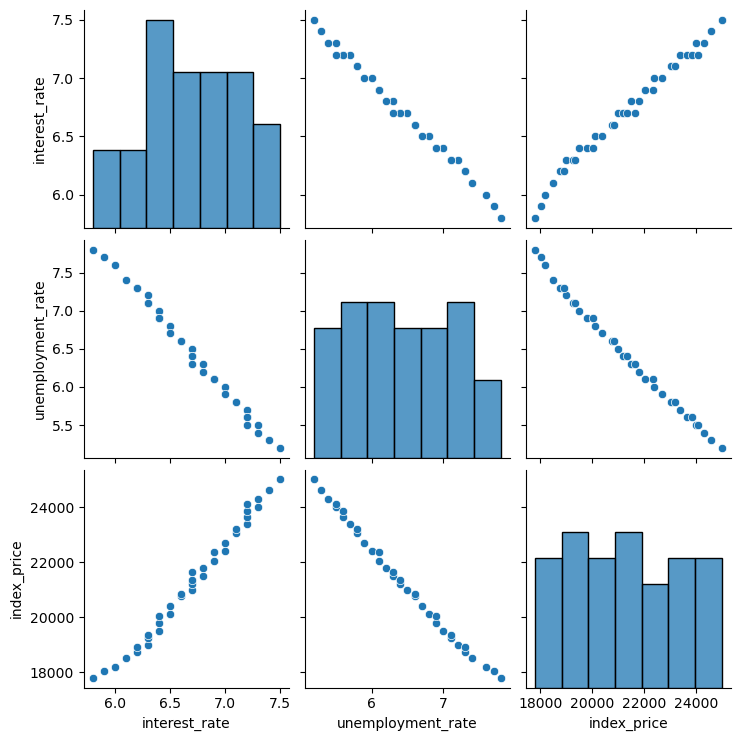

In [7]:
sns.pairplot(df)

In [8]:
df.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.997061,0.993123
unemployment_rate,-0.997061,1.000000,-0.997375
index_price,0.993123,-0.997375,1.000000


#### **Visualize data closely**

Text(0, 0.5, 'Unemployment Rate')

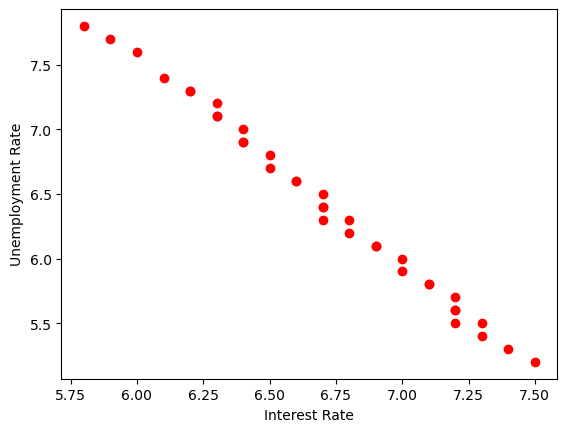

In [9]:
plt.scatter(df['interest_rate'],df['unemployment_rate'],color='r')
plt.xlabel("Interest Rate")
plt.ylabel("Unemployment Rate")

In [10]:
## Dependent and Undependent feature
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [13]:
import seaborn as sns

<Axes: xlabel='interest_rate', ylabel='index_price'>

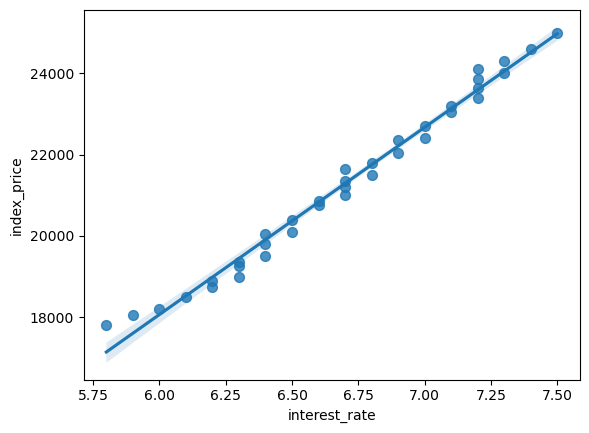

In [14]:
sns.regplot(x=df['interest_rate'],y=df['index_price'],scatter_kws={'s':50})

<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

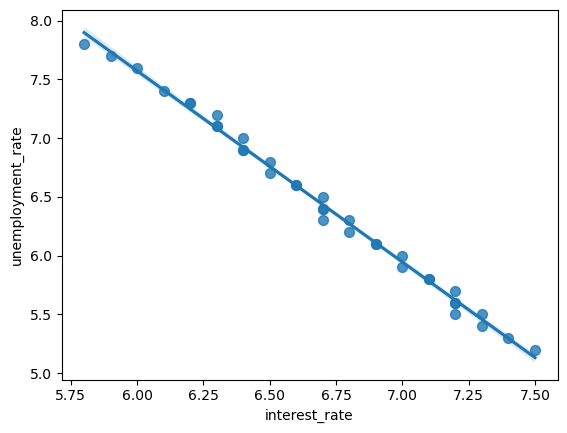

In [15]:
sns.regplot(x=df['interest_rate'],y=df['unemployment_rate'],scatter_kws={'s':50})

In [16]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [17]:
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [18]:
X_train

array([[ 0.11607969, -0.1613899 ],
       [-0.77939221,  0.79181921],
       [ 1.68315552, -1.65928994],
       [-1.89873209,  1.74502833],
       [-1.00326019,  1.06416468],
       [ 1.23541957, -1.25077175],
       [ 0.11607969, -0.02521717],
       [ 0.11607969, -0.1613899 ],
       [-0.77939221,  0.92799194],
       [-0.33165626,  0.38330102],
       [-1.67486412,  1.6088556 ],
       [ 0.56381564, -0.5699081 ],
       [-1.45099614,  1.47268287],
       [ 1.23541957, -1.38694448],
       [-1.22712816,  1.20033741],
       [ 1.45928755, -1.52311721],
       [ 0.78768362, -0.70608083],
       [ 1.23541957, -1.11459902],
       [-0.55552424,  0.51947375],
       [ 0.56381564, -0.5699081 ],
       [ 0.33994767, -0.29756263],
       [ 0.78768362, -0.84225356],
       [-1.00326019,  1.06416468],
       [ 0.33994767, -0.43373537],
       [-0.77939221,  0.79181921],
       [-0.10778828,  0.11095556],
       [ 1.01155159, -0.97842629]])

In [19]:
X_test

array([[ 1.9070235 , -1.79546268],
       [-0.33165626,  0.24712829],
       [ 1.01155159, -0.97842629],
       [ 1.45928755, -1.38694448],
       [-0.10778828,  0.11095556],
       [ 1.23541957, -1.25077175],
       [ 0.11607969, -0.29756263],
       [-0.55552424,  0.51947375],
       [-0.55552424,  0.65564648]])

In [20]:
from sklearn.linear_model import LinearRegression
regression=LinearRegression()

In [21]:
regression.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [22]:
from sklearn.model_selection import cross_val_score
validation_score=cross_val_score(regression,X_train,y_train,scoring='neg_mean_squared_error',cv=3)

In [23]:
np.mean(validation_score)

np.float64(-27289.86001224977)

In [24]:
y_pred=regression.predict(X_test)

In [25]:
y_pred

array([24627.98385617, 20603.06182352, 23018.01504311, 23822.99944964,
       20808.62869198, 23617.43258118, 21801.89689965, 20003.64428545,
       19609.79361585])

In [26]:
## Performance Metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [27]:
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

33895.29951485511
151.78315905338363
184.10676118723916


In [28]:
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred)
print(score)

0.9903367617179246


In [29]:
## display adjusted R-squared
1-(1-score)*(len(y_test))/(len(y_test) - X_test.shape[1] - 1)

0.9855051425768869

#### ***ASSUMPTIONS***

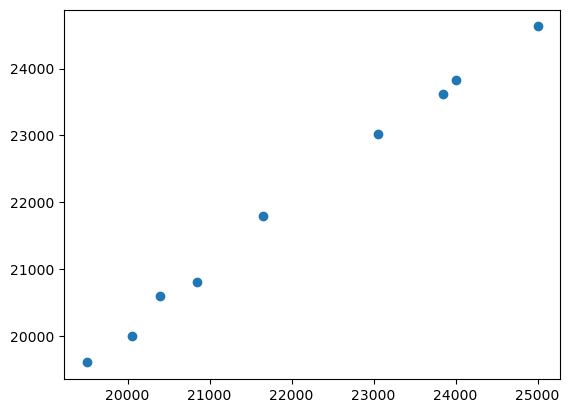

In [30]:
plt.scatter(y_test,y_pred)

In [31]:
residuals=y_test-y_pred
print(residuals)

35    372.016144
13   -203.061824
26     31.984957
30    177.000550
16     41.371308
31    232.567419
21   -151.896900
12     46.355715
8    -109.793616
Name: index_price, dtype: float64


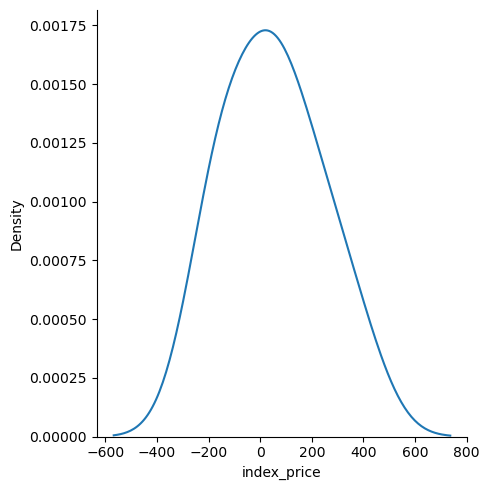

In [32]:
## Plot this residuals
sns.displot(residuals,kind='kde')

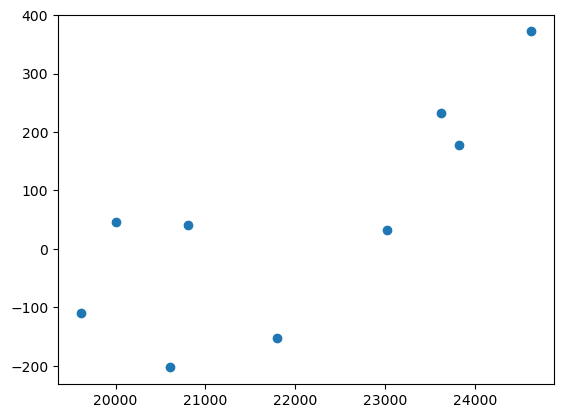

In [33]:
## Scatter plot wrt to prediction and residuals
plt.scatter(y_pred,residuals)

In [34]:
## OLS Linear Regression
import statsmodels.api as sm
model=sm.OLS(y_train,X_train).fit()
prediction=model.predict(X_test)
print(prediction)

[ 3589.09496728  -435.82706537  1979.12615422  2784.11056075
  -230.26019691  2578.54369229   763.00801076 -1035.24460344
 -1429.09527304]


In [35]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:            index_price   R-squared (uncentered):                   0.009
Model:                            OLS   Adj. R-squared (uncentered):             -0.070
Method:                 Least Squares   F-statistic:                             0.1192
Date:                Tue, 09 Jun 2026   Prob (F-statistic):                       0.888
Time:                        00:25:40   Log-Likelihood:                         -307.07
No. Observations:                  27   AIC:                                      618.1
Df Residuals:                      25   BIC:                                      620.7
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [36]:
print(regression.coef_)

[ -841.04839208 -2892.28736706]
